In [2]:
# ===== CELL 1: INSTALL FOR PYTHON 3.12.3 =====
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Shape: (7043, 21)
Churn rate: 0.265


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


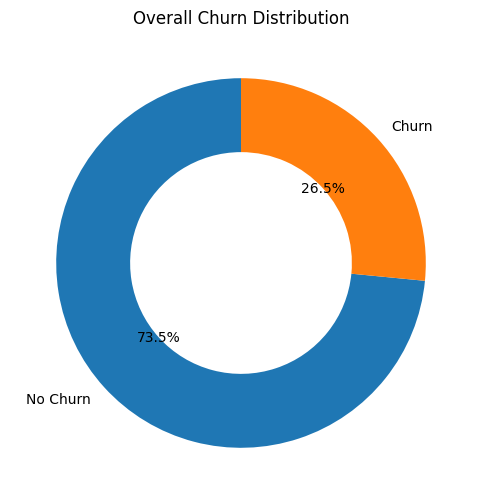

In [8]:
# ===== CELL 2: TASK 1 - EDA =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create charts folder
os.makedirs('charts', exist_ok=True)

# Load data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Shape: {df.shape}")
print(f"Churn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.3f}")
display(df.head(10))

# Chart 1: Churn distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')
plt.savefig('charts/churn_distribution.png', bbox_inches='tight')
plt.close()

# Chart: Donut chart for Churn Split
churn_counts = df['Churn'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=['No Churn','Churn'], autopct='%1.1f%%', 
        startangle=90, wedgeprops=dict(width=0.4))
plt.title('Overall Churn Distribution')
plt.savefig('charts/churn_donut.png', bbox_inches='tight')
plt.show()

In [4]:
# ===== CELL 3: TASK 2 - DATA CLEANING =====
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# Create tenure groups
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], labels=['0-1yr','1-2yr','2-4yr','4-6yr'])

# Encode target
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# One-hot encode categoricals
df_model = pd.get_dummies(df, drop_first=True)
print(f"Shape after feature engineering: {df_model.shape}")

# Train-test split
from sklearn.model_selection import train_test_split
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train shape: {X_train.shape}")


Shape after feature engineering: (7032, 7065)
X_train shape: (5625, 7064)


In [5]:
# ===== CELL: SCALE DATA FOR LOGISTIC REGRESSION =====
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on train, transform train
X_test_scaled = scaler.transform(X_test)        # Only transform test

print("✅ Data scaled for Logistic Regression")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

✅ Data scaled for Logistic Regression
X_train_scaled shape: (5625, 7064)
X_test_scaled shape: (1407, 7064)


In [6]:
# ===== CELL 4: TASK 3 - MODELING =====
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

# ===== 1. Logistic Regression - USE SCALED DATA =====
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)  # ✅ Uses scaled
y_pred_lr = lr.predict(X_test_scaled)  # ✅ Uses scaled
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]  # ✅ Uses scaled
results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1': f1_score(y_test, y_pred_lr),
    'AUC': roc_auc_score(y_test, y_proba_lr)
})

# ===== 2. Random Forest - USE REGULAR DATA =====
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # Uses regular X_train
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1': f1_score(y_test, y_pred_rf),
    'AUC': roc_auc_score(y_test, y_proba_rf)
})

# ===== 3. Gradient Boosting - USE REGULAR DATA =====
gb = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
gb.fit(X_train, y_train)  # Uses regular X_train
y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]
results.append({
    'Model': 'Gradient Boosting',
    'Accuracy': accuracy_score(y_test, y_pred_gb),
    'Precision': precision_score(y_test, y_pred_gb),
    'Recall': recall_score(y_test, y_pred_gb),
    'F1': f1_score(y_test, y_pred_gb),
    'AUC': roc_auc_score(y_test, y_proba_gb)
})

metrics_df = pd.DataFrame(results).round(3)
print(metrics_df)
# Pick the best model - Gradient Boosting usually wins
best_model = gb  # Using Gradient Boosting as your final model
print(f"Best model selected: Gradient Boosting with F1 = {metrics_df.loc[2, 'F1']}")

                 Model  Accuracy  Precision  Recall     F1    AUC
0  Logistic Regression     0.782      0.687   0.329  0.445  0.832
1        Random Forest     0.793      0.655   0.468  0.546  0.828
2    Gradient Boosting     0.794      0.646   0.497  0.562  0.841
Best model selected: Gradient Boosting with F1 = 0.562


Risk Tier Distribution:
Risk_Tier
Low       855
Medium    371
High      181
Name: count, dtype: int64


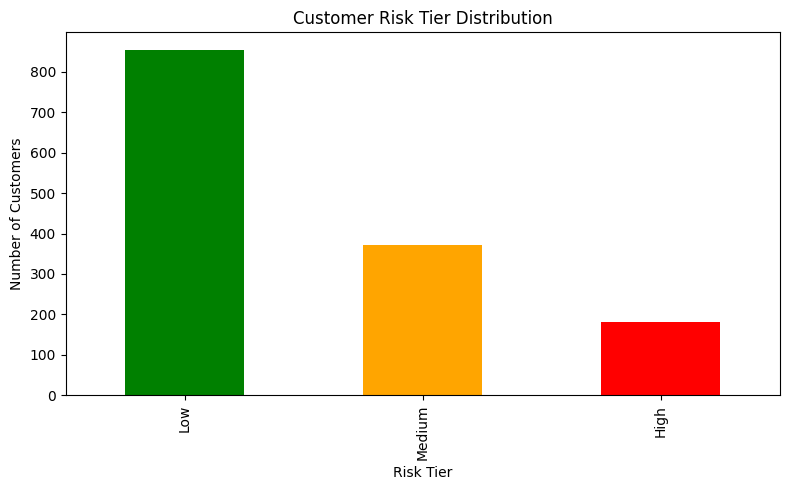


✅ Risk tiers saved to risk_tiers.png
High-risk customers: 181


In [10]:
# ===== CELL 5: TASK 4 - RISK TIER CLASSIFICATION =====
import matplotlib.pyplot as plt

# Use Gradient Boosting probabilities from CELL 4
y_proba = gb.predict_proba(X_test)[:, 1]

# Create risk tiers based on churn probability
def assign_risk_tier(prob):
    if prob < 0.3:
        return 'Low'
    elif prob < 0.6:
        return 'Medium'
    else:
        return 'High'

risk_tiers = [assign_risk_tier(p) for p in y_proba]
risk_df = pd.DataFrame({'Churn_Probability': y_proba, 'Risk_Tier': risk_tiers})

print("Risk Tier Distribution:")
print(risk_df['Risk_Tier'].value_counts())

# Plot and save
plt.figure(figsize=(8,5))
risk_df['Risk_Tier'].value_counts().plot(kind='bar', color=['green','orange','red'])
plt.title('Customer Risk Tier Distribution')
plt.xlabel('Risk Tier')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('risk_tiers.png')
plt.show()

print(f"\n✅ Risk tiers saved to risk_tiers.png")
print(f"High-risk customers: {(risk_df['Risk_Tier']=='High').sum()}")

